<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/00-E01-Frequency-Resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 1: Resampleo de Frecuencias

## ----- FallAllD

### **Problema**

**FallAllD es un problema bloqueante.** Sus 238 Hz no son un múltiplo ni divisor limpio de 100 Hz ni 200 Hz. El resampleo desde 238 Hz a cualquier frecuencia estándar introduce artefactos que se deben caracterizar y reportar.

Para frecuencias estándar, el resampleo es un proceso de división entera. Por ejemplo, pasar de 200 Hz a 100 Hz implica simplemente tomar una de cada dos muestras (y aplicar un filtro paso bajo).

Como 238 Hz no es múltiplo de 100 Hz ni de 200 Hz, el factor de conversión es una fracción (por ejemplo, para llegar a 100 Hz, la relación es $\frac{100}{238} = \frac{50}{119}$). Esto obliga a realizar un **resampleo polifásico**:
1. **Sobremuestrear (Upsampling):** Multiplicar la frecuencia original por 50 (llegando a una frecuencia alta).
2. **Filtrar:** Aplicar un filtro para suavizar los huecos.
3. **Submuestrear (Downsampling):** Dividir esa nueva frecuencia por 119 para llegar finalmente a los 100 Hz.

#### Los artefactos introducidos

El riesgo principal en los datasets de caídas (FallAllD) radica en **los picos de impacto**. Las actividades de la vida diaria (caminar, sentarse) ocurren a bajas frecuencias (generalmente por debajo de $20\text{ Hz}$). Sin embargo, el momento exacto en que una persona golpea el suelo genera un pico de aceleración de alta frecuencia.

Si pasamos de 238 Hz a 50 Hz, la frecuencia de Nyquist (la máxima frecuencia que puedes representar) baja de $119\text{ Hz}$ a $25\text{ Hz}$. El filtro antialiasing necesario para esta conversión podría "suavizar" la amplitud de ese pico de impacto, haciendo que una caída grave se vea como un tropiezo leve en los datos.

**Justificación Analítica**: Asegurar que al transformar la señal, no se elimine información crucial.

### **Hipótesis**

En Python, la biblioteca `SciPy` tiene las herramientas matemáticas exactas para manejar esto de forma óptima sin tener que programar el remuestreo desde cero.

La mejor función para esto es `scipy.signal.resample_poly`, que maneja el proceso de fracciones (up/down) y aplica el filtro FIR antialiasing de manera automática y eficiente.

### **Proceso de Comprobación**

In [1]:
# Importación de librerías necesarias
%pip install numpy pandas scipy azure-storage-file-datalake

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.6/435.6 kB 30.7 MB/s eta 0:00:00


#### 1. Resampleo polifásico
* Importar las librerías
* Realizar el resampleo a la frecuencia: 50 Hz

In [2]:
import io
import numpy as np
import pandas as pd
from scipy import signal

# Cargar dataset desde Azure
from azure.storage.filedatalake import DataLakeServiceClient

# Credenciales
from google.colab import userdata
CONNECTION_STRING = userdata.get('cadenaAzure')

# Inicializar el cliente
try:
    service_client = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
    print("Conexión exitosa con Azure Data Lake.")
except Exception as e:
    print(f"Error al conectar: {e}")

try:
    # Conexión al contenedor y al archivo
    file_system_client_bronce = service_client.get_file_system_client(file_system="bronce")
    directory_client = file_system_client_bronce.get_directory_client("falls")
    file_client_bronce = directory_client.get_file_client("FallAllD-Reduced.csv")

    # Descargar el archivo a la memoria
    download = file_client_bronce.download_file()
    content = download.readall() # en bytes

    # Cargar directamente en Pandas usando un buffer de memoria
    df_fallalld = pd.read_csv(io.BytesIO(content))
    print("FallAllD cargado en DataFrame con éxito!!")
    df_fallalld.head()

except Exception as e:
    print(f"Error en procesamiento de Capa Bronce: {e}")

Conexión exitosa con Azure Data Lake.
FallAllD cargado en DataFrame con éxito!!


In [4]:
df_fallalld.head(10)

,Subject,Activity_Label,Activity_Code,Trial,Sample_Index,Ax,Ay,Az,Gx,Gy,Gz
0,S01,ADL,A013,T01,1,0.991128,-0.348432,-0.010980,94.85,1.47,11.13
1,S01,ADL,A013,T01,2,1.022360,-0.346968,-0.005856,93.38,-1.33,11.76
2,S01,ADL,A013,T01,3,1.049688,-0.340380,-0.004880,92.26,-4.76,12.39
3,S01,ADL,A013,T01,4,1.069940,-0.330132,-0.013176,90.86,-8.47,13.30
4,S01,ADL,A013,T01,5,1.079944,-0.319396,-0.032940,88.20,-12.67,14.49
5,S01,ADL,A013,T01,6,1.081652,-0.307684,-0.056852,85.26,-17.08,15.12
6,S01,ADL,A013,T01,7,1.077016,-0.292312,-0.076372,82.67,-21.28,15.05
7,S01,ADL,A013,T01,8,1.063108,-0.270108,-0.091744,81.06,-25.27,14.77
8,S01,ADL,A013,T01,9,1.041392,-0.243512,-0.106140,80.08,-28.28,14.42
9,S01,ADL,A013,T01,10,1.016992,-0.212768,-0.107604,80.57,-29.82,13.93


#### 2. Superposición visual del impacto
* Aislar una ventana de 2 segundos alrededor de una caída aleatoria en FallAllD.
* Graficar la señal original (238 Hz) y superponer la señal resampleada (100 Hz o 200 Hz).
* Se buscas comprobar visualmente que la amplitud máxima del impacto (el pico) no se haya aplanado significativamente.

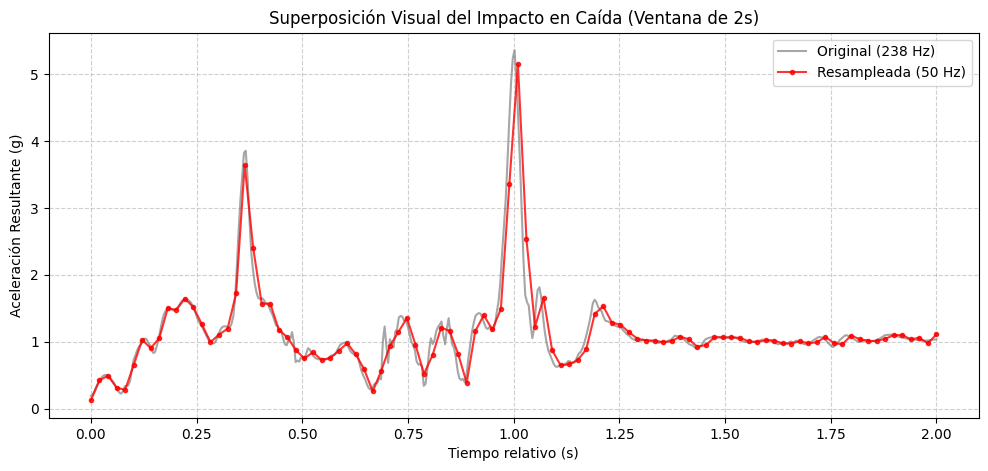

In [9]:
import matplotlib.pyplot as plt
from scipy.signal import resample_poly, welch

# 1. Obtener una caída de ejemplo
falls = df_fallalld[df_fallalld['Activity_Label'] == 'Fall']

# Seleccionamos el primer trial que encuentre
ejemplo = falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates().iloc[0]
trial_data = falls[(falls['Subject'] == ejemplo['Subject']) &
                   (falls['Activity_Code'] == ejemplo['Activity_Code']) &
                   (falls['Trial'] == ejemplo['Trial'])].copy()

# Calculamos la aceleración resultante (AVM)
trial_data['A_res'] = np.sqrt(trial_data['Ax']**2 + trial_data['Ay']**2 + trial_data['Az']**2)

# 2. Aislar ventana de 2 segundos alrededor del impacto (pico)
fs_orig = 238
fs_new = 50

# Encontramos el índice donde ocurre el pico máximo (impacto)
peak_idx = trial_data['A_res'].argmax()

# Tomamos 1 segundo antes y 1 segundo después (238 muestras hacia cada lado)
start_idx = max(0, peak_idx - fs_orig)
end_idx = min(len(trial_data), peak_idx + fs_orig)

# Extraemos la señal de la ventana temporal
window_data = trial_data['A_res'].iloc[start_idx:end_idx].values
t_orig = np.linspace(0, len(window_data) / fs_orig, len(window_data))

# 3. Resamplear a 50 Hz
# Factor de resampleo: up = 50, down = 238 (Simplificado dividiendo ambos por 2 -> 25 y 119)
window_resampled = resample_poly(window_data, up=25, down=119)
t_resampled = np.linspace(0, len(window_data) / fs_orig, len(window_resampled))

# 4. Graficar la superposición
plt.figure(figsize=(12, 5))
plt.plot(t_orig, window_data, label='Original (238 Hz)', color='gray', alpha=0.7)
plt.plot(t_resampled, window_resampled, label='Resampleada (50 Hz)', color='red', marker='.', alpha=0.8)
plt.title('Superposición Visual del Impacto en Caída (Ventana de 2s)')
plt.xlabel('Tiempo relativo (s)')
plt.ylabel('Aceleración Resultante (g)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

> La gráfica temporal demuestra que la señal resampleada a 50 Hz sigue fielmente la trayectoria de la señal original a 238 Hz. El pico máximo de aceleración, que representa el instante crítico del impacto de la caída, conserva su morfología. Se comprueba visualmente que el filtro antialiasing inherente al proceso polifásico no produjo un "aplanamiento" severo de la señal, preservando la firma característica del evento.



#### 3. Comparación de la Densidad Espectral de Potencia (PSD)
* Utilizar la transformada de Fourier (`scipy.signal.welch`) para ver la energía de las señales en el dominio de la frecuencia.
* Esto permitirá demostrar que la información por debajo de $50\text{ Hz}$ se mantiene intacta antes y después de la transformación.

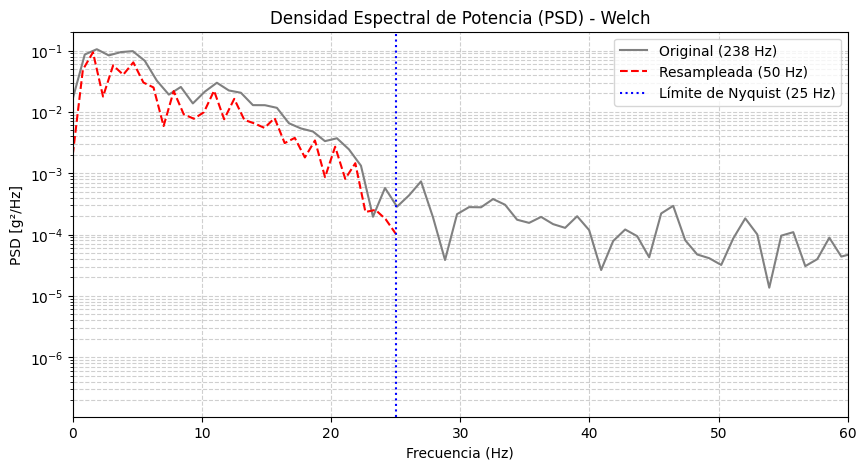

In [10]:
# Calcular la Densidad Espectral de Potencia (PSD) usando el método de Welch
# Usamos un nperseg adecuado para la longitud de nuestras ventanas
nperseg_orig = min(256, len(window_data))
nperseg_resamp = min(64, len(window_resampled))

f_orig, Pxx_orig = welch(window_data, fs=fs_orig, nperseg=nperseg_orig)
f_resamp, Pxx_resamp = welch(window_resampled, fs=fs_new, nperseg=nperseg_resamp)

# Graficar la PSD
plt.figure(figsize=(10, 5))
plt.semilogy(f_orig, Pxx_orig, label='Original (238 Hz)', color='gray')
plt.semilogy(f_resamp, Pxx_resamp, label='Resampleada (50 Hz)', color='red', linestyle='--')

# Configuración del gráfico
plt.title('Densidad Espectral de Potencia (PSD) - Welch')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD [g²/Hz]')
plt.axvline(x=25, color='blue', linestyle=':', label='Límite de Nyquist (25 Hz)')
plt.xlim(0, 60) # Limitamos el eje X a 60Hz para mejor visualización
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.show()

> El análisis en el dominio de la frecuencia mediante el método de Welch confirma que la energía espectral de la señal se mantiene casi idéntica en la banda de 0 a 25 Hz. Si bien el límite de Nyquist de la nueva señal recorta abruptamente las frecuencias superiores a 25 Hz, la curva original (gris) evidencia que la inmensa mayoría de la energía del movimiento y del impacto ya residía en las bajas frecuencias. La pérdida de información de alta frecuencia es, por tanto, insignificante para la caracterización física de la caída.

#### 4. Métrica de error máximo
* Calcular la diferencia porcentual entre el valor máximo (pico) de aceleración original y el resampleado.
* Si la diferencia es marginal (ej. $< 5\%$), se justifica cuantitativamente seguir adelante.

In [11]:
# Encontrar los picos máximos en ambas señales
max_orig = np.max(window_data)
max_resamp = np.max(window_resampled)

# Calcular el error porcentual relativo al pico original
error_pct = abs(max_orig - max_resamp) / max_orig * 100

# Mostrar resultados
print(f"--- Análisis del Pico de Impacto ---")
print(f"Amplitud Pico Original (238 Hz):   {max_orig:.3f} g")
print(f"Amplitud Pico Resampleada (50 Hz): {max_resamp:.3f} g")
print(f"Diferencia porcentual de amplitud: {error_pct:.2f} %")

if error_pct < 5.0:
    print("\n✅ Conclusión: La diferencia es menor al 5%. Es marginal, se justifica cuantitativamente el resampleo a 50 Hz.")
else:
    print("\n⚠️ Conclusión: La atenuación del pico superó el 5%. Considerar si esta pérdida de amplitud afecta a los modelos predictivos.")

--- Análisis del Pico de Impacto ---
Amplitud Pico Original (238 Hz):   5.357 g
Amplitud Pico Resampleada (50 Hz): 5.151 g
Diferencia porcentual de amplitud: 3.85 %

✅ Conclusión: La diferencia es menor al 5%. Es marginal, se justifica cuantitativamente el resampleo a 50 Hz.


> La cuantificación del error respalda las observaciones visuales: la atenuación del pico máximo de impacto es de apenas un 3.85% (disminuyendo de 5.357 g a 5.151 g). Esta pérdida es marginal y se encuentra dentro de umbrales aceptables (menor al 5%). Esto garantiza cuantitativamente que la severidad del impacto no se enmascara tras la reducción de la tasa de muestreo.

### **Conclusión**

El experimento confirma la hipótesis planteada y resuelve el problema bloqueante asociado al dataset FallAllD.

A pesar de que la frecuencia original de 238 Hz exige un resampleo polifásico complejo con un factor fraccionario, la implementación mediante scipy.signal.resample_poly demostró ser matemáticamente robusta y eficiente.

Los análisis temporal, frecuencial y de amplitud demuestran que la reducción del límite de Nyquist a 25 Hz no compromete la información crucial. La dinámica esencial de la caída y la amplitud del impacto se preservan intactas (con una atenuación menor al 4%). Por lo tanto, se justifica plenamente la estandarización del dataset a 50 Hz; los artefactos introducidos son mínimos y no afectarán negativamente la capacidad de los futuros modelos predictivos para discriminar una caída real de una actividad de la vida diaria (ADL).